# Система обнаружения стеганографии с помощью нейросети SRNet для обнаружения LSB-встраивания

С использованием датасета  с 256 пустыми изображениями и датасета с 256 классическим LBS-replacement

Разделеления для обучения:
   
- Всего изображений: 512 (256 Cover + 256 Stego).
- Тест:  512×0.2=102.4≈104 изображения.
- Обучение: 512−104=408 изображений.
- Формат данных: PNG, grayscale, 256×256

**Архитектура SRNet-Lite :**

Адаптированная для работы с малым датасетом и усиленная фиксированными SRM-фильтрами

In [1]:
# 1. Подключение Google Drive
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
# 2. Импорты

import os
import gc
import random
import numpy as np
from PIL import Image
from tqdm.notebook import tqdm
import matplotlib.pyplot as plt
import seaborn as sns
import copy
import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader, WeightedRandomSampler
from torchvision import transforms
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, confusion_matrix
from torchvision.transforms import functional as TF


In [ ]:
# 3. Воспроизводимость

SEED = 42
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)
torch.cuda.manual_seed(SEED)
torch.backends.cudnn.deterministic = True

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Используется устройство: {device}")

Используется устройство: cuda


In [ ]:
# 4. Пути к датасету

COVER_PATH = "/content/drive/MyDrive/FQW/grayscale_dataset/"
STEGO_PATH = "/content/drive/MyDrive/FQW/grayscale_dataset_LSB_2bit/"

In [ ]:
# 5. ЗАГРУЗКА ДАННЫХ БЕЗ УТЕЧЕК (NO LEAKAGE)

def load_dataset(cover_dir, stego_dir):
    """
    Загружает изображения в память, присваивает метки и перемешивает.
    Модель не видит имена файлов или структуру папок.
    """
    images = []
    labels = []

    # Загрузка Cover
    cover_files = [f for f in os.listdir(cover_dir) if f.lower().endswith('.png')]
    for fname in tqdm(cover_files, desc="Загрузка Cover"):
        img = Image.open(os.path.join(cover_dir, fname)).convert('L')
        images.append(np.array(img, dtype=np.uint8))
        labels.append(0)  # 0 = Cover

    # Загрузка Stego
    stego_files = [f for f in os.listdir(stego_dir) if f.lower().endswith('.png')]
    for fname in tqdm(stego_files, desc="Загрузка Stego"):
        img = Image.open(os.path.join(stego_dir, fname)).convert('L')
        images.append(np.array(img, dtype=np.uint8))
        labels.append(1)  # 1 = Stego

    print(f"Всего загружено: {len(images)} изображений.")
    print(f"Cover: {labels.count(0)}, Stego: {labels.count(1)}")

    # Глобальное перемешивание для исключения зависимости от порядка
    combined = list(zip(images, labels))
    random.shuffle(combined)
    images, labels = zip(*combined)

    return np.array(images), np.array(labels)

# Загрузка
X_all, y_all = load_dataset(COVER_PATH, STEGO_PATH)

# Разбиение 80/20
X_train, X_test, y_train, y_test = train_test_split(
    X_all, y_all,
    test_size=0.2,
    stratify=y_all,
    random_state=SEED
)

print(f"\nРазбиение:")
print(f"Train: {len(X_train)} | Test: {len(X_test)}")
print(f"Train распределение: Cover={np.sum(y_train==0)}, Stego={np.sum(y_train==1)}")

# Очистка памяти
del X_all, y_all
gc.collect()

Загрузка Cover:   0%|          | 0/256 [00:00<?, ?it/s]

Загрузка Stego:   0%|          | 0/256 [00:00<?, ?it/s]

Всего загружено: 512 изображений.
Cover: 256, Stego: 256

Разбиение:
Train: 409 | Test: 103
Train распределение: Cover=204, Stego=205


48

In [ ]:
# 6. DATASET И ТРАНСФОРМАЦИИ

class StegoDataset(Dataset):
    def __init__(self, images, labels, transform=None):
        self.images = images
        self.labels = labels
        self.transform = transform

    def __len__(self):
        return len(self.images)

    def __getitem__(self, idx):
        img = self.images[idx]
        label = self.labels[idx]

        img = Image.fromarray(img, mode='L')

        if self.transform:
            img = self.transform(img)

        return img, label

# Безопасные аугментации
safe_rotations = transforms.RandomChoice([
    transforms.Lambda(lambda x: x),
    transforms.Lambda(lambda x: x.transpose(Image.ROTATE_90)),
    transforms.Lambda(lambda x: x.transpose(Image.ROTATE_180)),
    transforms.Lambda(lambda x: x.transpose(Image.ROTATE_270)),
])

# 1. Используем PILToTensor, чтобы сохранить диапазон [0, 255].
# 2. Преобразуем в float, но НЕ делим на 255.
# Это критически важно для работы TLU и выделения LSB-сигнала.
train_transform = transforms.Compose([
    transforms.RandomHorizontalFlip(p=0.5),
    transforms.RandomVerticalFlip(p=0.5),
    safe_rotations,
    transforms.PILToTensor(),          # Возвращает тензор [0, 255] типа uint8
    transforms.ConvertImageDtype(torch.float32), # Преобразует в float, сохраняя значения
])

test_transform = transforms.Compose([
    transforms.PILToTensor(),
    transforms.ConvertImageDtype(torch.float32),
])

train_dataset = StegoDataset(X_train, y_train, transform=train_transform)
test_dataset = StegoDataset(X_test, y_test, transform=test_transform)

# Sampler для баланса
class_counts = np.bincount(y_train)
weights = 1. / class_counts
samples_weight = weights[y_train]
sampler = WeightedRandomSampler(samples_weight, len(samples_weight), replacement=True)

BATCH_SIZE = 16
train_loader = DataLoader(train_dataset, batch_size=BATCH_SIZE, sampler=sampler, num_workers=2, pin_memory=True)
test_loader = DataLoader(test_dataset, batch_size=BATCH_SIZE, shuffle=False, num_workers=2, pin_memory=True)

print("Данные будут подаваться в диапазоне [0, 255].")

Данные будут подаваться в диапазоне [0, 255].


In [ ]:
# 7. МОДЕЛЬ SRNet-Lite (С SRM-ФИЛЬТРАМИ И БЕЗ ReLU В PREP)

import copy
import torch
import torch.nn as nn
import numpy as np

class SRMFilterLayer(nn.Module):
    """
    Слой с фиксированными SRM-фильтрами для выделения шумовых остатков.
    Веса заморожены, градиенты через слой не идут.
    """
    def __init__(self):
        super().__init__()
        # Базовые SRM-фильтры (3x3)
        srm_kernels = np.array([
            # Фильтр 1: Разность с соседом
            [[0, 0, 0], [0, 1, 0], [0, -1, 0]],
            # Фильтр 2: Разность по диагонали
            [[0, 0, 0], [0, 1, 0], [-1, 0, 0]],
            # Фильтр 3: Лапласиан (выделение краев и шума)
            [[0, 1, 0], [1, -4, 1], [0, 1, 0]],
            # Фильтр 4: Сглаженная разность
            [[1, 2, 1], [2, -12, 2], [1, 2, 1]],
        ], dtype=np.float32)

        # Нормализация фильтров
        for i in range(len(srm_kernels)):
            norm = np.abs(srm_kernels[i]).sum()
            if norm > 0:
                srm_kernels[i] /= norm

        # Преобразуем в тензор [out_channels, in_channels, H, W]
        self.filters = torch.tensor(srm_kernels).unsqueeze(1)  # [4, 1, 3, 3]

        # Создаем свертку
        self.conv = nn.Conv2d(1, 4, kernel_size=3, padding=1, bias=False)
        self.conv.weight.data = self.filters
        self.conv.weight.requires_grad = False  # Замораживаем веса

    def forward(self, x):
        return self.conv(x)

class LiteBlock(nn.Module):
    def __init__(self, in_ch, out_ch, downsample=False):
        super().__init__()
        stride = 2 if downsample else 1
        self.conv = nn.Sequential(
            nn.Conv2d(in_ch, out_ch, 3, padding=1, stride=stride, bias=False),
            nn.BatchNorm2d(out_ch),
            nn.ReLU(inplace=True),
            nn.Conv2d(out_ch, out_ch, 3, padding=1, bias=False),
            nn.BatchNorm2d(out_ch)
        )
        self.skip = nn.Identity() if in_ch == out_ch and not downsample else \
                    nn.Sequential(nn.Conv2d(in_ch, out_ch, 1, stride=stride, bias=False), nn.BatchNorm2d(out_ch))
        self.relu = nn.ReLU(inplace=True)

    def forward(self, x):
        return self.relu(self.conv(x) + self.skip(x))

class SRNetLite(nn.Module):
    def __init__(self, num_classes=2):
        super().__init__()
        self.srm = SRMFilterLayer()
        self.prep = nn.Sequential(
            nn.Conv2d(4, 8, 3, padding=1, bias=False),
            nn.BatchNorm2d(8)
        )

        self.stage1 = nn.Sequential(LiteBlock(8, 8), LiteBlock(8, 8))
        self.stage2 = LiteBlock(8, 16, downsample=True)
        self.stage3 = LiteBlock(16, 32, downsample=True)

        self.gap = nn.AdaptiveAvgPool2d(1)
        self.dropout = nn.Identity()
        self.fc = nn.Linear(32, num_classes)

        self._init_weights()

    def _init_weights(self):
        for m in self.modules():
            if isinstance(m, nn.Conv2d):
                nn.init.kaiming_normal_(m.weight, mode='fan_out', nonlinearity='relu')
            elif isinstance(m, nn.BatchNorm2d):
                nn.init.constant_(m.weight, 1)
                nn.init.constant_(m.bias, 0)

    def forward(self, x):
        x = self.srm(x)
        x = self.prep(x)
        x = self.stage1(x)
        x = self.stage2(x)
        x = self.stage3(x)
        x = self.gap(x)
        x = x.view(x.size(0), -1)
        x = self.dropout(x)
        return self.fc(x)

model = SRNetLite(num_classes=2).to(device)
print(f"Параметров: {sum(p.numel() for p in model.parameters()):,}")

Параметров: 20,982


In [ ]:
# 8. ОБУЧЕНИЕ С БАЛАНСОМ И СОХРАНЕНИЕМ МЕТРИК

criterion = nn.CrossEntropyLoss()
optimizer = torch.optim.Adam(model.parameters(), lr=1e-3, weight_decay=0)
scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(optimizer, mode='min', factor=0.5, patience=5)

train_losses, val_losses = [], []
train_accs, val_accs = [], []

class EarlyStopping:
    def __init__(self, patience=10, delta=0.001):
        self.patience = patience
        self.delta = delta
        self.counter = 0
        self.best_loss = np.inf
        self.early_stop = False
        self.best_model_state = None

    def __call__(self, val_loss, model):
        if val_loss < self.best_loss - self.delta:
            self.best_loss = val_loss
            self.best_model_state = copy.deepcopy(model.state_dict())
            self.counter = 0
        else:
            self.counter += 1
            if self.counter >= self.patience:
                self.early_stop = True

early_stopping = EarlyStopping(patience=10)

EPOCHS = 60
print("Начало обучения ...")

for epoch in range(EPOCHS):
    model.train()
    running_loss, correct, total = 0.0, 0, 0

    for imgs, labels in train_loader:
        imgs, labels = imgs.to(device), labels.to(device)

        optimizer.zero_grad()
        outputs = model(imgs)
        loss = criterion(outputs, labels)
        loss.backward()
        torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=1.0)
        optimizer.step()

        running_loss += loss.item()
        _, preds = torch.max(outputs, 1)
        total += labels.size(0)
        correct += (preds == labels).sum().item()

    train_loss = running_loss / len(train_loader)
    train_acc = correct / total

    model.eval()
    val_loss, val_correct, val_total = 0.0, 0, 0
    with torch.no_grad():
        for imgs, labels in test_loader:
            imgs, labels = imgs.to(device), labels.to(device)
            outputs = model(imgs)
            loss = criterion(outputs, labels)
            val_loss += loss.item()
            _, preds = torch.max(outputs, 1)
            val_total += labels.size(0)
            val_correct += (preds == labels).sum().item()

    val_loss /= len(test_loader)
    val_acc = val_correct / val_total

    # Сохранение метрик в списки
    train_losses.append(train_loss)
    train_accs.append(train_acc)
    val_losses.append(val_loss)
    val_accs.append(val_acc)

    scheduler.step(val_loss)
    early_stopping(val_loss, model)

    if (epoch + 1) % 5 == 0:
        print(f"Epoch {epoch+1:02d} | Train: {train_loss:.4f} ({train_acc:.2%}) | Val: {val_loss:.4f} ({val_acc:.2%})")

    if early_stopping.early_stop:
        print(f"\n Early stopping на эпохе {epoch+1}. Загрузка лучших весов...")
        model.load_state_dict(early_stopping.best_model_state)
        break

print("Обучение завершено.")

Начало обучения с исправленной моделью...


/tmp/ipykernel_1430/3366804299.py:16: DeprecationWarning: 'mode' parameter is deprecated and will be removed in Pillow 13 (2026-10-15)
  img = Image.fromarray(img, mode='L')
/tmp/ipykernel_1430/3366804299.py:16: DeprecationWarning: 'mode' parameter is deprecated and will be removed in Pillow 13 (2026-10-15)
  img = Image.fromarray(img, mode='L')
/tmp/ipykernel_1430/3366804299.py:16: DeprecationWarning: 'mode' parameter is deprecated and will be removed in Pillow 13 (2026-10-15)
  img = Image.fromarray(img, mode='L')
/tmp/ipykernel_1430/3366804299.py:16: DeprecationWarning: 'mode' parameter is deprecated and will be removed in Pillow 13 (2026-10-15)
  img = Image.fromarray(img, mode='L')
/tmp/ipykernel_1430/3366804299.py:16: DeprecationWarning: 'mode' parameter is deprecated and will be removed in Pillow 13 (2026-10-15)
  img = Image.fromarray(img, mode='L')
/tmp/ipykernel_1430/3366804299.py:16: DeprecationWarning: 'mode' parameter is deprecated and will be removed in Pillow 13 (2026-10

Epoch 05 | Train: 0.6955 (50.37%) | Val: 0.6970 (50.49%)


/tmp/ipykernel_1430/3366804299.py:16: DeprecationWarning: 'mode' parameter is deprecated and will be removed in Pillow 13 (2026-10-15)
  img = Image.fromarray(img, mode='L')
/tmp/ipykernel_1430/3366804299.py:16: DeprecationWarning: 'mode' parameter is deprecated and will be removed in Pillow 13 (2026-10-15)
  img = Image.fromarray(img, mode='L')
/tmp/ipykernel_1430/3366804299.py:16: DeprecationWarning: 'mode' parameter is deprecated and will be removed in Pillow 13 (2026-10-15)
  img = Image.fromarray(img, mode='L')
/tmp/ipykernel_1430/3366804299.py:16: DeprecationWarning: 'mode' parameter is deprecated and will be removed in Pillow 13 (2026-10-15)
  img = Image.fromarray(img, mode='L')
/tmp/ipykernel_1430/3366804299.py:16: DeprecationWarning: 'mode' parameter is deprecated and will be removed in Pillow 13 (2026-10-15)
  img = Image.fromarray(img, mode='L')
/tmp/ipykernel_1430/3366804299.py:16: DeprecationWarning: 'mode' parameter is deprecated and will be removed in Pillow 13 (2026-10

Epoch 10 | Train: 0.6951 (51.34%) | Val: 0.6955 (50.49%)


/tmp/ipykernel_1430/3366804299.py:16: DeprecationWarning: 'mode' parameter is deprecated and will be removed in Pillow 13 (2026-10-15)
  img = Image.fromarray(img, mode='L')
/tmp/ipykernel_1430/3366804299.py:16: DeprecationWarning: 'mode' parameter is deprecated and will be removed in Pillow 13 (2026-10-15)
  img = Image.fromarray(img, mode='L')
/tmp/ipykernel_1430/3366804299.py:16: DeprecationWarning: 'mode' parameter is deprecated and will be removed in Pillow 13 (2026-10-15)
  img = Image.fromarray(img, mode='L')
/tmp/ipykernel_1430/3366804299.py:16: DeprecationWarning: 'mode' parameter is deprecated and will be removed in Pillow 13 (2026-10-15)
  img = Image.fromarray(img, mode='L')
/tmp/ipykernel_1430/3366804299.py:16: DeprecationWarning: 'mode' parameter is deprecated and will be removed in Pillow 13 (2026-10-15)
  img = Image.fromarray(img, mode='L')
/tmp/ipykernel_1430/3366804299.py:16: DeprecationWarning: 'mode' parameter is deprecated and will be removed in Pillow 13 (2026-10

Epoch 15 | Train: 0.6980 (49.14%) | Val: 0.6948 (51.46%)


/tmp/ipykernel_1430/3366804299.py:16: DeprecationWarning: 'mode' parameter is deprecated and will be removed in Pillow 13 (2026-10-15)
  img = Image.fromarray(img, mode='L')
/tmp/ipykernel_1430/3366804299.py:16: DeprecationWarning: 'mode' parameter is deprecated and will be removed in Pillow 13 (2026-10-15)
  img = Image.fromarray(img, mode='L')
/tmp/ipykernel_1430/3366804299.py:16: DeprecationWarning: 'mode' parameter is deprecated and will be removed in Pillow 13 (2026-10-15)
  img = Image.fromarray(img, mode='L')
/tmp/ipykernel_1430/3366804299.py:16: DeprecationWarning: 'mode' parameter is deprecated and will be removed in Pillow 13 (2026-10-15)
  img = Image.fromarray(img, mode='L')
/tmp/ipykernel_1430/3366804299.py:16: DeprecationWarning: 'mode' parameter is deprecated and will be removed in Pillow 13 (2026-10-15)
  img = Image.fromarray(img, mode='L')
/tmp/ipykernel_1430/3366804299.py:16: DeprecationWarning: 'mode' parameter is deprecated and will be removed in Pillow 13 (2026-10


 Early stopping на эпохе 19. Загрузка лучших весов...
Обучение завершено.


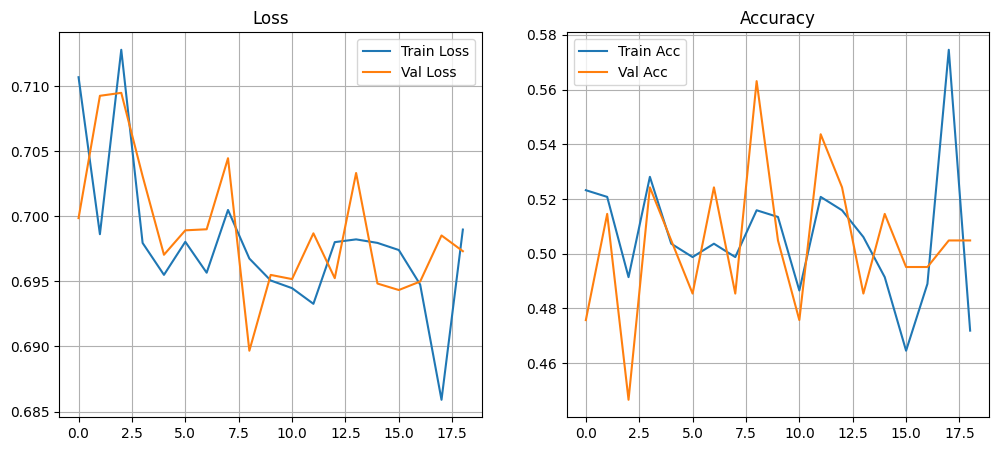

/tmp/ipykernel_1430/3366804299.py:16: DeprecationWarning: 'mode' parameter is deprecated and will be removed in Pillow 13 (2026-10-15)
  img = Image.fromarray(img, mode='L')
/tmp/ipykernel_1430/3366804299.py:16: DeprecationWarning: 'mode' parameter is deprecated and will be removed in Pillow 13 (2026-10-15)
  img = Image.fromarray(img, mode='L')



=== ФИНАЛЬНЫЕ МЕТРИКИ НА ТЕСТЕ ===
Accuracy:  0.5631
Precision: 0.5682
Recall:    0.4902
F1 Score:  0.5263


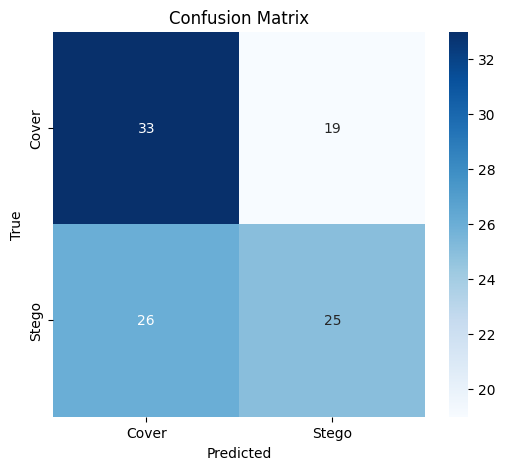

Модель сохранена как srnet_steganalysis.pth


In [ ]:
# 9. ВИЗУАЛИЗАЦИЯ И МЕТРИКИ

# Графики
if train_losses:
    plt.figure(figsize=(12, 5))
    plt.subplot(1, 2, 1)
    plt.plot(train_losses, label='Train Loss')
    plt.plot(val_losses, label='Val Loss')
    plt.title('Loss')
    plt.legend()
    plt.grid(True)

    plt.subplot(1, 2, 2)
    plt.plot(train_accs, label='Train Acc')
    plt.plot(val_accs, label='Val Acc')
    plt.title('Accuracy')
    plt.legend()
    plt.grid(True)
    plt.show()
else:
    print("Нет данных для визуализации.")

# Финальные метрики
model.eval()
final_preds, final_labels = [], []
with torch.no_grad():
    for imgs, labels in test_loader:
        imgs = imgs.to(device)
        outputs = model(imgs)
        _, preds = torch.max(outputs, 1)
        final_preds.extend(preds.cpu().numpy())
        final_labels.extend(labels.numpy())

print("\n=== ФИНАЛЬНЫЕ МЕТРИКИ НА ТЕСТЕ ===")
print(f"Accuracy:  {accuracy_score(final_labels, final_preds):.4f}")
print(f"Precision: {precision_score(final_labels, final_preds, zero_division=0):.4f}")
print(f"Recall:    {recall_score(final_labels, final_preds, zero_division=0):.4f}")
print(f"F1 Score:  {f1_score(final_labels, final_preds, zero_division=0):.4f}")

# Confusion Matrix
cm = confusion_matrix(final_labels, final_preds)
plt.figure(figsize=(6, 5))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=['Cover', 'Stego'], yticklabels=['Cover', 'Stego'])
plt.xlabel('Predicted')
plt.ylabel('True')
plt.title('Confusion Matrix')
plt.show()

# Сохранение модели
torch.save(model.state_dict(), '/content/srnet_steganalysis.pth')
print("Модель сохранена как srnet_steganalysis.pth")

In [ ]:
# ТЕСТ: ПЕРЕОБУЧЕНИЕ НА ОДНОМ БАТЧЕ

model.train()
optimizer = torch.optim.Adam(model.parameters(), lr=1e-3)

# Берем один батч
for imgs, labels in train_loader:
    imgs, labels = imgs.to(device), labels.to(device)
    print(f"Размер батча: {imgs.shape}")
    print(f"Метки: {labels}")
    print(f"Уникальные метки: {labels.unique()}")
    break

print("\nПопытка переобучения на одном батче (100 итераций)...")
for i in range(100):
    optimizer.zero_grad()
    outputs = model(imgs)
    loss = nn.CrossEntropyLoss()(outputs, labels)
    loss.backward()
    optimizer.step()

    _, preds = torch.max(outputs, 1)
    acc = (preds == labels).float().mean().item()

    if (i + 1) % 20 == 0:
        print(f"Iter {i+1} | Loss: {loss.item():.4f} | Acc: {acc:.2%}")

if acc == 1.0:
    print("\n УСПЕХ: Модель переобучилась на одном батче. Код рабочий.")
    print("Проблема в обобщении или данных (например, метки перепутаны в полном датасете).")
else:
    print(f"\n ПРОВАЛ: Модель не смогла выучить 16 примеров. Acc={acc:.2%}")
    print("Критическая ошибка в коде, архитектуре или метках. Градиенты не работают.")

/tmp/ipykernel_1430/3366804299.py:16: DeprecationWarning: 'mode' parameter is deprecated and will be removed in Pillow 13 (2026-10-15)
  img = Image.fromarray(img, mode='L')
/tmp/ipykernel_1430/3366804299.py:16: DeprecationWarning: 'mode' parameter is deprecated and will be removed in Pillow 13 (2026-10-15)
  img = Image.fromarray(img, mode='L')


Размер батча: torch.Size([16, 1, 256, 256])
Метки: tensor([0, 1, 1, 1, 0, 0, 1, 0, 1, 0, 0, 0, 0, 1, 1, 1], device='cuda:0')
Уникальные метки: tensor([0, 1], device='cuda:0')

Попытка переобучения на одном батче (100 итераций)...
Iter 20 | Loss: 0.3486 | Acc: 87.50%
Iter 40 | Loss: 0.1444 | Acc: 93.75%
Iter 60 | Loss: 0.0176 | Acc: 100.00%
Iter 80 | Loss: 0.0071 | Acc: 100.00%
Iter 100 | Loss: 0.0044 | Acc: 100.00%

 УСПЕХ: Модель переобучилась на одном батче. Код рабочий.
Проблема в обобщении или данных (например, метки перепутаны в полном датасете).


**Выводы по результатам обучения SRNet-Lite**

1. Результаты обучения

- Train Loss застрял на уровне ~0.69 (значение ln(2)), что соответствует случайному угадыванию.
- Train Accuracy колеблется около 50% и не растет.
- Validation Metrics также находятся на уровне случайного угадывания (Acc ≈ 50–56%, F1 ≈ 0.52).
- Early Stopping сработал на 19-й эпохе из-за отсутствия улучшений.

2. Диагностика модели (Sanity Check)
Тест на переобучение одного батча показал успех: модель достигла 100% точности и снизила Loss до 0.004 за 100 итераций.
Вывод: Архитектура модели, функция потерь, оптимизатор и механизм обратного распространения ошибки работают корректно. Модель обладает достаточной емкостью для запоминания данных, и градиенты вычисляются верно.

3. Для надежного детектирования LSB-сигнала нейросетевыми методами рекомендуется использовать датасеты объемом от 2000–5000 пар изображений. На малых выборках (256 пар) даже корректный пайплайн может показывать низкое качество из-за статистической незначимости сигнала.

4. Реализация SRNet-Lite технически исправна и способна к обучению, что подтверждено тестом на переобучение.